Sprint 3: Descriptive Analysis
This notebook performs descriptive analysis of Canada's labour market using the final modeling dataset created in Sprint 2.

Dataset:

final_dataset.csv
Goal:

Understand historical trends
Explore job vacancies, unemployment, and labour market imbalance (θ)
Identify pre-COVID, COVID, and post-COVID patterns
No data cleaning is performed here.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../1_data/processed/final_dataset.csv")

df['month'] = pd.to_datetime(df['month'])

df.head()

,month,Employment,Labour force,Population,Unemployment,vacancies,theta
0,2015-04-01,17819.4,19156.6,29000.4,1337.2,440425.0,329.363596
1,2015-05-01,17843.7,19168.4,29020.2,1324.7,407040.0,307.269570
2,2015-06-01,17836.7,19163.3,29048.8,1326.6,398910.0,300.701040
3,2015-07-01,17863.3,19199.2,29074.3,1336.0,376570.0,281.863772
4,2015-08-01,17889.0,19247.3,29099.5,1358.3,369190.0,271.802989


In [2]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   month         117 non-null    datetime64[ns]
 1   Employment    117 non-null    float64       
 2   Labour force  117 non-null    float64       
 3   Population    117 non-null    float64       
 4   Unemployment  117 non-null    float64       
 5   vacancies     111 non-null    float64       
 6   theta         111 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 6.5 KB


(117, 7)

In [3]:
df.isna().sum()

month           0
Employment      0
Labour force    0
Population      0
Unemployment    0
vacancies       6
theta           6
dtype: int64

In [4]:
df[['vacancies','Unemployment','theta']].describe()

,vacancies,Unemployment,theta
count,111.000000,117.000000,111.000000
mean,591755.675676,1342.066667,474.080945
std,186221.428492,297.410572,186.912264
min,340915.000000,1007.100000,241.133824
25%,440520.000000,1154.500000,329.083471
50%,543600.000000,1273.000000,437.226340
75%,677945.000000,1397.200000,537.655887
max,988430.000000,2720.500000,976.705392


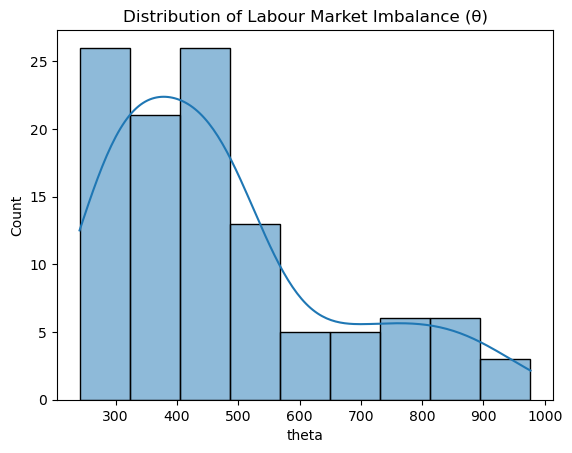

In [5]:
sns.histplot(df['theta'], kde=True)
plt.title("Distribution of Labour Market Imbalance (θ)")
plt.show()

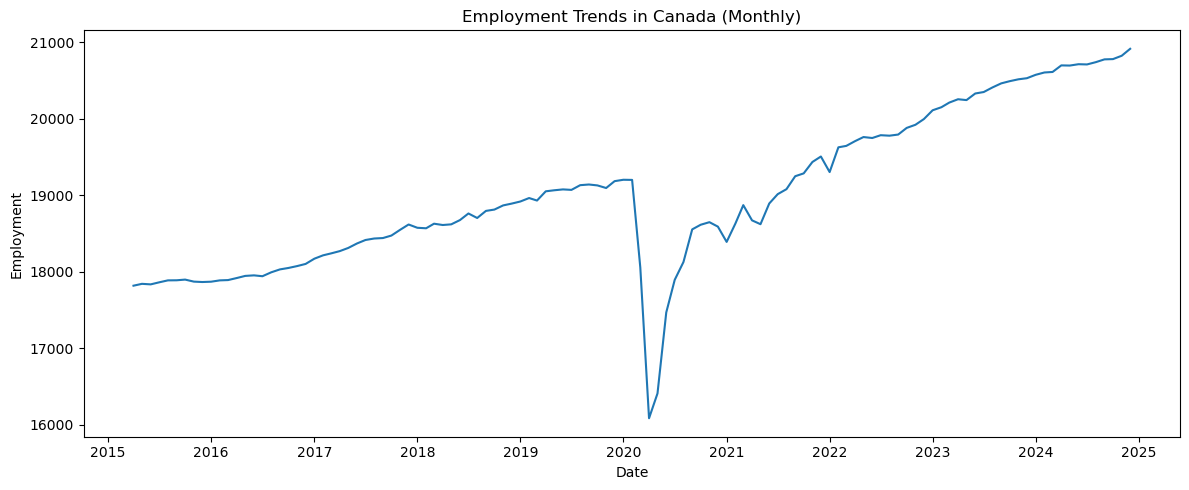

In [6]:
# Task #29: Employment trend (run fifth)
# =========================
plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["Employment"])
plt.title("Employment Trends in Canada (Monthly)")
plt.xlabel("Date")
plt.ylabel("Employment")
plt.tight_layout()
plt.show()

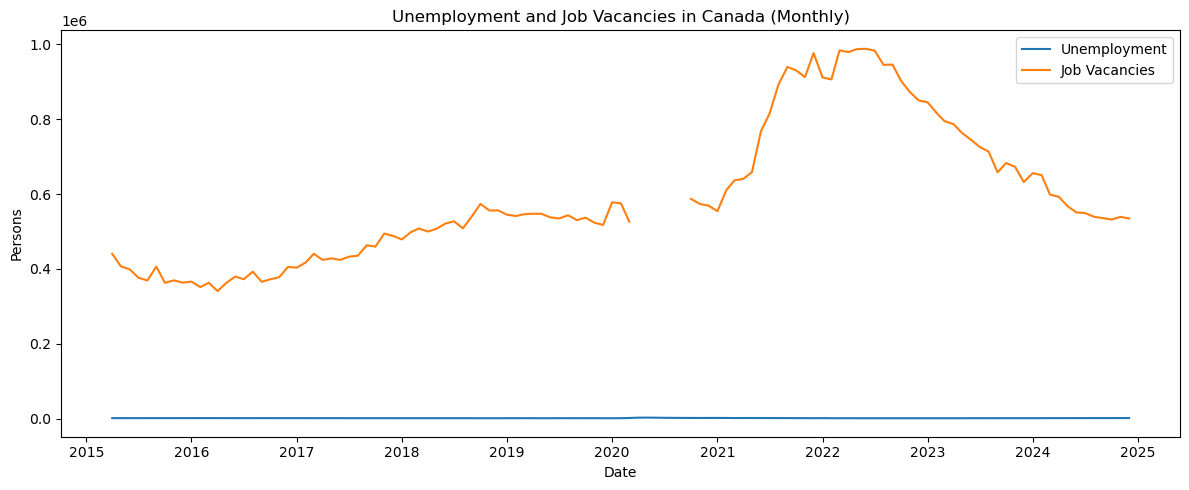

In [7]:
# =========================
# Task #30: Unemployment and job vacancies (run sixth)
# =========================
plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["Unemployment"], label="Unemployment")
plt.plot(df["month"], df["vacancies"], label="Job Vacancies")
plt.title("Unemployment and Job Vacancies in Canada (Monthly)")
plt.xlabel("Date")
plt.ylabel("Persons")
plt.legend()
plt.tight_layout()
plt.show()

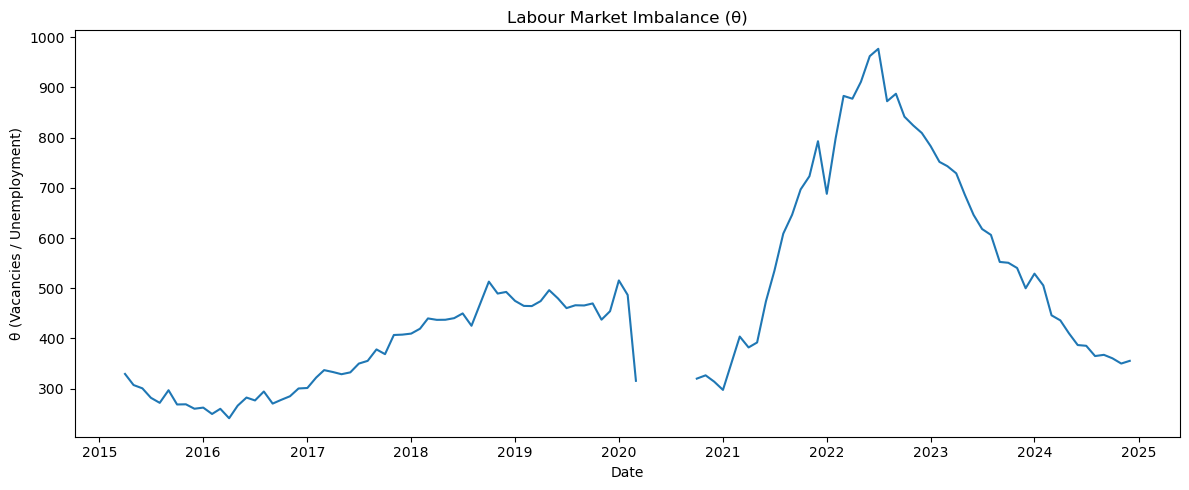

In [8]:
# =========================
# — θ (already exists): plot labour market imbalance (run seventh)
# =========================
plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["theta"])
plt.title("Labour Market Imbalance (θ)")
plt.xlabel("Date")
plt.ylabel("θ (Vacancies / Unemployment)")
plt.tight_layout()
plt.show()

/var/folders/dj/5wn4pm8j3js3m4yf_dgnkx6h0000gn/T/ipykernel_62804/258627849.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["theta_growth"] = df["theta"].pct_change()


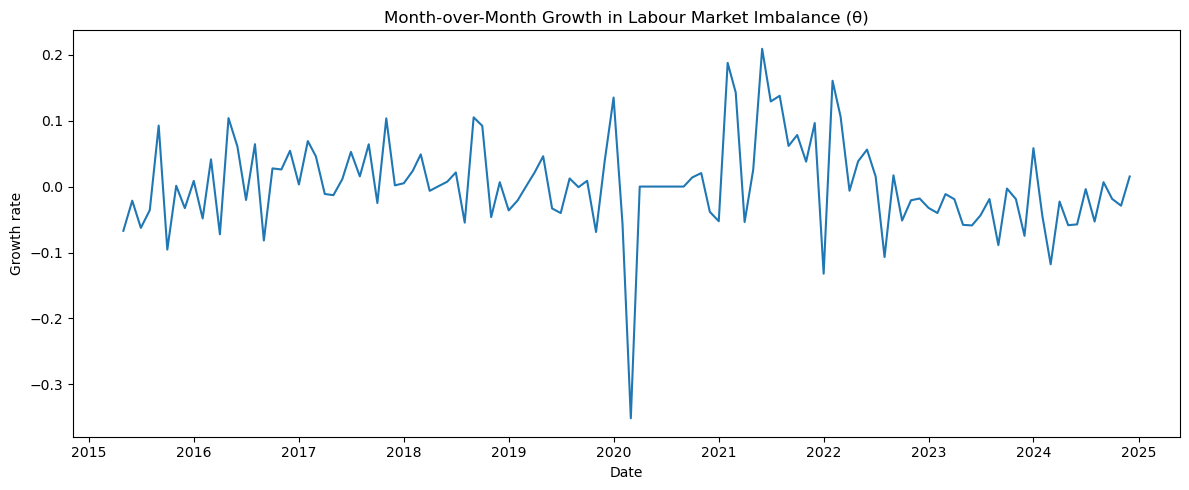

,month,theta,theta_growth
0,2015-04-01,329.363596,NaN
1,2015-05-01,307.269570,-0.067081
2,2015-06-01,300.701040,-0.021377
3,2015-07-01,281.863772,-0.062645
4,2015-08-01,271.802989,-0.035694
5,2015-09-01,296.938030,0.092475
6,2015-10-01,268.557159,-0.095578
7,2015-11-01,268.890991,0.001243


In [10]:
# =========================
# — Growth rate of θ (advanced descriptive) (run eighth)
# =========================
df["theta_growth"] = df["theta"].pct_change()

plt.figure(figsize=(12, 5))
plt.plot(df["month"], df["theta_growth"])
plt.title("Month-over-Month Growth in Labour Market Imbalance (θ)")
plt.xlabel("Date")
plt.ylabel("Growth rate")
plt.tight_layout()
plt.show()

# Quick check
display(df[["month", "theta", "theta_growth"]].head(8))

In [11]:
# =========================
#Task #31: Define period (Pre-COVID vs COVID & Post) (run ninth)
# =========================
df["period"] = df["month"].apply(lambda x: "Pre-COVID" if x < pd.to_datetime("2020-03-01") else "COVID & Post")

# add year column derived from month to avoid KeyError  in later analysis

df["year"] = df["month"].dt.year

# Quick check
print(df["period"].value_counts())
display(df[["month", "year", "period"]].head())

period
Pre-COVID       59
COVID & Post    58
Name: count, dtype: int64


,month,year,period
0,2015-04-01,2015,Pre-COVID
1,2015-05-01,2015,Pre-COVID
2,2015-06-01,2015,Pre-COVID
3,2015-07-01,2015,Pre-COVID
4,2015-08-01,2015,Pre-COVID


In [12]:
# =========================
#Task #31: Pre- vs Post-COVID descriptive summary table (run tenth)
# =========================
covid_summary = (
    df.groupby("period")[["Employment", "Unemployment", "vacancies", "theta"]]
    .agg(["mean", "median", "std", "min", "max"])
)

covid_summary

Employment                                           \
                      mean    median          std      min      max   
period                                                                
COVID & Post  19584.129310  19784.35  1085.979210  16085.8  20917.4   
Pre-COVID     18452.667797  18442.50   471.169235  17819.4  19204.7   

             Unemployment                                           vacancies  \
                     mean   median         std     min     max           mean   
period                                                                          
COVID & Post  1436.348276  1339.25  390.614600  1007.1  2720.5  741201.730769   
Pre-COVID     1249.383051  1225.50   96.590028  1103.1  1413.8  460040.508475   

                                                                theta  \
                median            std       min       max        mean   
period                                                                  
COVID & Post  719905.0  160233.579352  526180.0  988430.0  586.844362   
Pre-COVID     459760.0   74307.469671  340915.0  578160.0  374.696239   

                                                              
                  median         std         min         max  
period                                                        
COVID & Post  551.531442  205.684243  297.555544  976.705392  
Pre-COVID     368.752005   87.237541  241.133824  515.523852

,month_num,Employment,Unemployment,vacancies,theta
0,1,19014.911111,1298.022222,593305.555556,473.474898
1,2,19096.277778,1275.344444,596613.888889,483.506642
2,3,19011.655556,1311.922222,599929.444444,476.967342
3,4,18710.500000,1410.150000,583694.444444,471.020871
4,5,18753.570000,1423.430000,581153.888889,470.612070


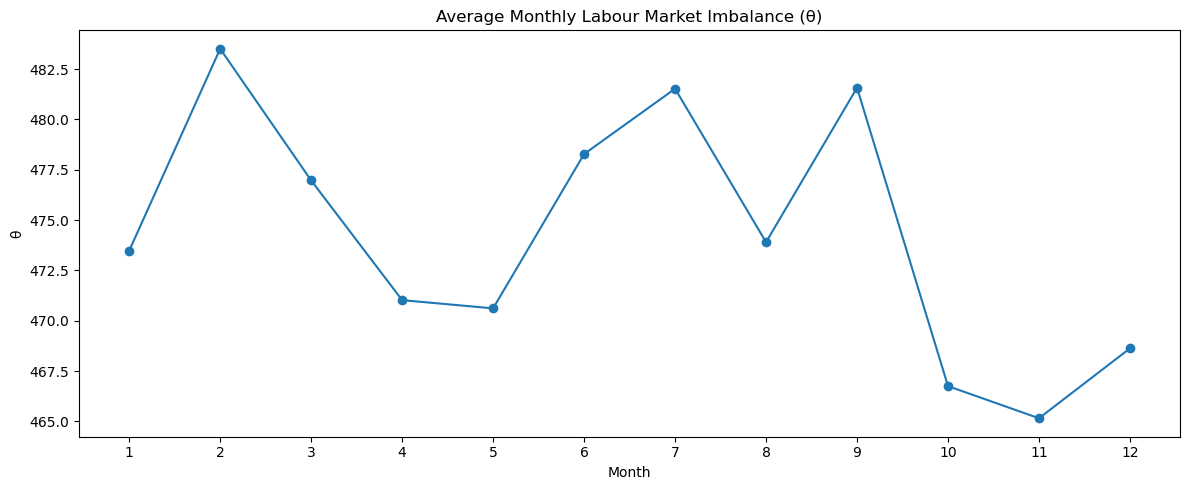

In [13]:
# =========================
# Seasonal descriptive patterns (month-of-year) (run eleventh)
# =========================
# ensure month_num exists (derived from the datetime month)
df['month_num'] = df['month'].dt.month

seasonal_summary = (
    df.groupby("month_num")[["Employment", "Unemployment", "vacancies", "theta"]]
    .mean()
    .reset_index()
)

display(seasonal_summary.head())

plt.figure(figsize=(12, 5))
plt.plot(seasonal_summary["month_num"], seasonal_summary["theta"], marker="o")
plt.title("Average Monthly Labour Market Imbalance (θ)")
plt.xlabel("Month")
plt.ylabel("θ")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

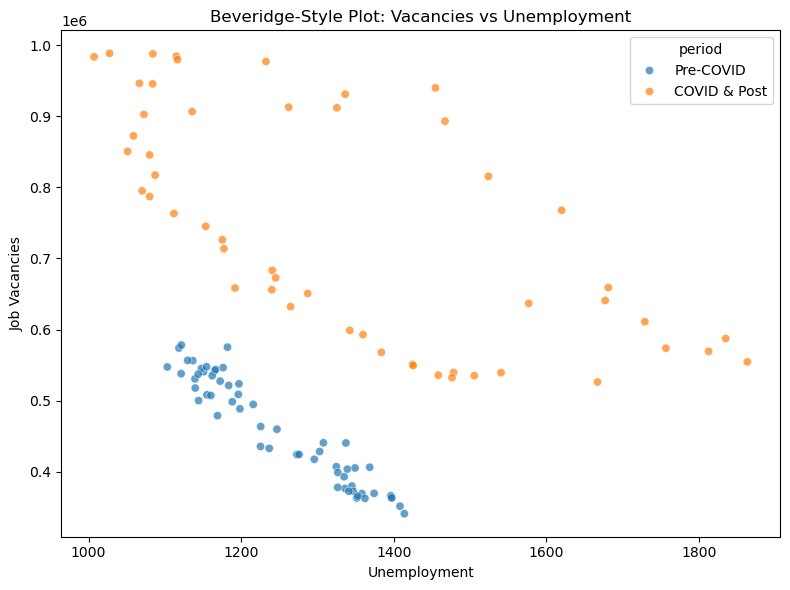

In [14]:
# =========================
# Beveridge-style scatter (descriptive only) (run twelfth)
# =========================
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Unemployment",
    y="vacancies",
    hue="period",
    alpha=0.7
)
plt.title("Beveridge-Style Plot: Vacancies vs Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Job Vacancies")
plt.tight_layout()
plt.show()

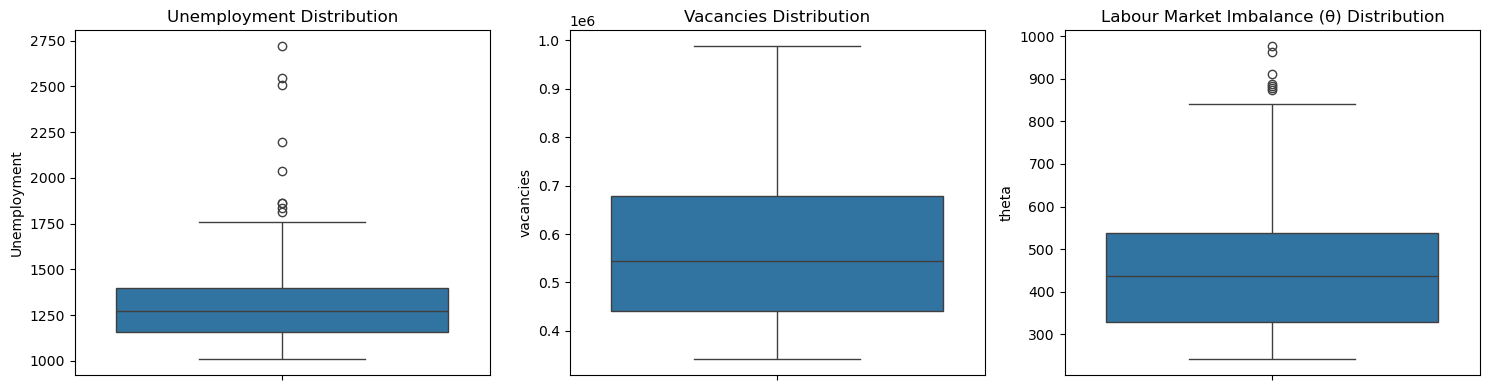

In [15]:
# =========================
# Distribution & tail behaviour (run thirteenth)
# =========================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df["Unemployment"], ax=axs[0])
axs[0].set_title("Unemployment Distribution")

sns.boxplot(y=df["vacancies"], ax=axs[1])
axs[1].set_title("Vacancies Distribution")

sns.boxplot(y=df["theta"], ax=axs[2])
axs[2].set_title("Labour Market Imbalance (θ) Distribution")

plt.tight_layout()
plt.show()

In [16]:
# =========================
# Descriptive correlations (reported only) (run fourteenth)
# =========================
corr_full = df["vacancies"].corr(df["Unemployment"])
corr_pre = df[df["period"] == "Pre-COVID"]["vacancies"].corr(df[df["period"] == "Pre-COVID"]["Unemployment"])
corr_post = df[df["period"] == "COVID & Post-COVID"]["vacancies"].corr(df[df["period"] == "COVID & Post-COVID"]["Unemployment"])

print("Descriptive correlation (Vacancies vs Unemployment):")
print(f"Full sample: {corr_full:.3f}")
print(f"Pre-COVID: {corr_pre:.3f}")
print(f"COVID & Post-COVID: {corr_post:.3f}")

Descriptive correlation (Vacancies vs Unemployment):
Full sample: -0.277
Pre-COVID: -0.958
COVID & Post-COVID: nan
